In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/organizations/uciml/sms-spam-collection-dataset/spam.csv


In [2]:
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv("/kaggle/input/datasets/organizations/uciml/sms-spam-collection-dataset/spam.csv",
                    encoding='latin-1'
)

In [4]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [6]:
df.drop(columns=["Unnamed: 2","Unnamed: 3","Unnamed: 4"], inplace = True)

In [9]:
df.head()

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [8]:
df.rename(columns = {"v1" : "target","v2":"text"}, inplace = True)

In [10]:
from sklearn.preprocessing import LabelEncoder

In [11]:
encoder = LabelEncoder()


In [12]:
df["target"] = encoder.fit_transform(df["target"])

In [13]:
df[df.duplicated()]

,target,text
102,0,As per your request 'Melle Melle (Oru Minnamin...
153,0,As per your request 'Melle Melle (Oru Minnamin...
206,0,"As I entered my cabin my PA said, '' Happy B'd..."
222,0,"Sorry, I'll call later"
325,0,No calls..messages..missed calls
...,...,...
5524,1,You are awarded a SiPix Digital Camera! call 0...
5535,0,"I know you are thinkin malaria. But relax, chi..."
5539,0,Just sleeping..and surfing
5553,0,Hahaha..use your brain dear


In [14]:
df = df.drop_duplicates()

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


# EDA

In [17]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

In [18]:
import plotly.express as px

In [19]:
#.bar( df['target'].value_counts())
counts = df['target'].value_counts().reset_index()
counts.columns = ['target', 'count']

px.bar(counts, x='target', y='count',color ="target")

In [20]:
import nltk

In [21]:
nltk.download("punkt")

[nltk_data] Error loading punkt: <urlopen error [Errno -3] Temporary
[nltk_data]     failure in name resolution>


False

In [22]:
df["char_num"] =df["text"].apply(len)

In [23]:
df.head()

,target,text,char_num
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [24]:
df["word_num"]  = df["text"].apply(lambda x : len(nltk.word_tokenize(x)))

In [25]:
df["sent_num"]  = df["text"].apply(lambda x : len(nltk.sent_tokenize(x)))

In [26]:
df.head()

,target,text,char_num,word_num,sent_num
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [27]:
df[df["target"] == 1][["char_num","word_num","sent_num"]].describe()

,char_num,word_num,sent_num
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [28]:
df[df["target"] == 0][["char_num","word_num","sent_num"]].describe()

,char_num,word_num,sent_num
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [29]:
import plotly.express as px

px.box(df, x="target", y="char_num")

In [30]:

px.box(df, x="target", y="sent_num")

In [31]:
px.box(df, x="target", y="word_num")

In [32]:
px.histogram(
    df,
    x="char_num",
    color="target",
    barmode="overlay"
)

In [33]:
px.scatter_matrix(
    df,
    dimensions=["char_num","word_num","sent_num"],
    color="target"
)

In [34]:
df[["char_num","word_num","sent_num"]].corr()

,char_num,word_num,sent_num
char_num,1.000000,0.965760,0.624139
word_num,0.965760,1.000000,0.679971
sent_num,0.624139,0.679971,1.000000


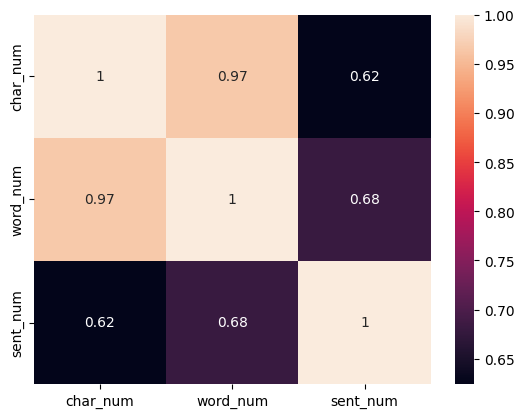

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    df[["char_num","word_num","sent_num"]].corr(),
    annot=True
)
plt.show()

In [36]:
spam_text = " ".join(df[df["target"]==1]["text"])

In [37]:
px.histogram(
    df,
    x="word_num",
    color="target",
    marginal="box"
)

In [38]:
from scipy.stats import ttest_ind

spam = df[df["target"]==1]["char_num"]
ham = df[df["target"]==0]["char_num"]

ttest_ind(spam, ham)

TtestResult(statistic=np.float64(29.960063305591103), pvalue=np.float64(5.506291455262007e-182), df=np.float64(5167.0))

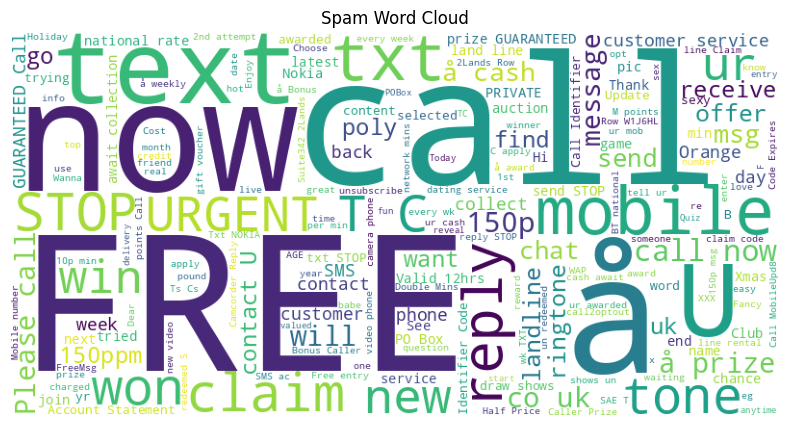

In [39]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

spam_text = " ".join(df[df["target"] == 1]["text"])

wc = WordCloud(
    width=800,
    height=400,
    background_color="white"
)

spam_wc = wc.generate(spam_text)

plt.figure(figsize=(10,5))
plt.imshow(spam_wc)
plt.axis("off")
plt.title("Spam Word Cloud")
plt.show()

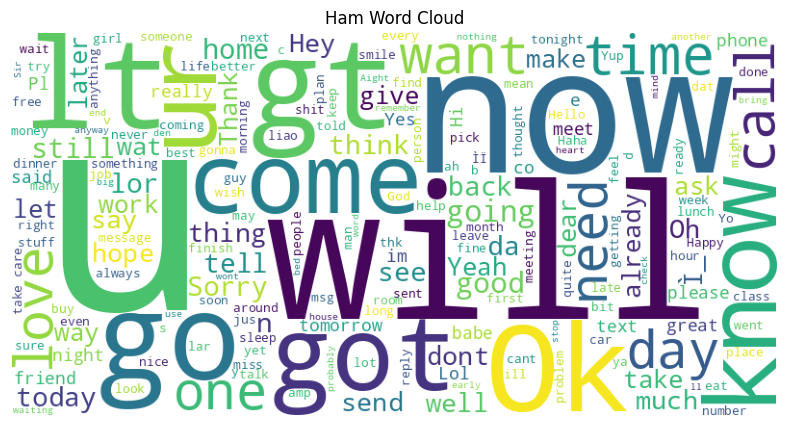

In [40]:
ham_text = " ".join(df[df["target"] == 0]["text"])

wc = WordCloud(
    width=800,
    height=400,
    background_color="white"
)

ham_wc = wc.generate(ham_text)

plt.figure(figsize=(10,5))
plt.imshow(ham_wc)
plt.axis("off")
plt.title("Ham Word Cloud")
plt.show()

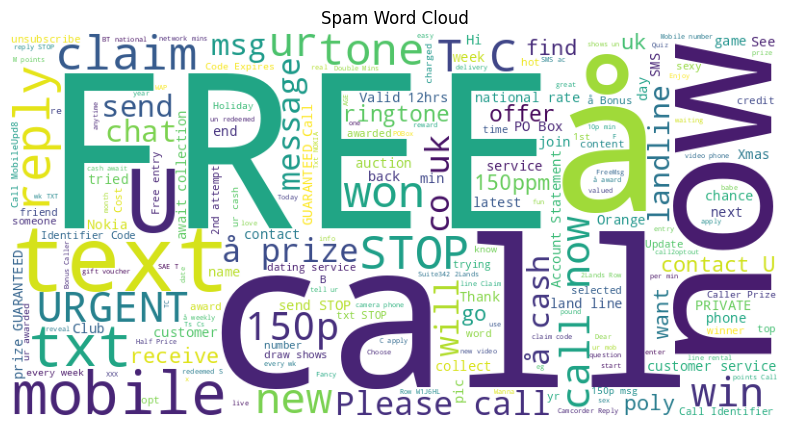

In [41]:
from wordcloud import WordCloud, STOPWORDS

wc = WordCloud(
    width=800,
    height=400,
    background_color="white",
    stopwords=STOPWORDS
)

spam_wc_ = wc.generate(spam_text)
plt.figure(figsize=(10,5))
plt.imshow(spam_wc_)
plt.axis("off")
plt.title("Spam Word Cloud")
plt.show()

In [42]:
from collections import Counter

spam_words = []

for msg in df[df["target"] == 1]["text"]:
    spam_words.extend(msg.split())

Counter(spam_words).most_common(20)

[('to', 522),
 ('a', 314),
 ('your', 171),
 ('call', 163),
 ('the', 160),
 ('or', 155),
 ('for', 152),
 ('2', 151),
 ('you', 150),
 ('is', 130),
 ('Call', 116),
 ('on', 112),
 ('have', 110),
 ('from', 109),
 ('and', 102),
 ('&', 89),
 ('with', 86),
 ('ur', 86),
 ('of', 79),
 ('FREE', 75)]

In [43]:
import pandas as pd
import plotly.express as px

common = pd.DataFrame(
    Counter(spam_words).most_common(20),
    columns=["word", "count"]
)

px.bar(common, x="word", y="count")

In [44]:
from collections import Counter

notspam_words = []

for msg in df[df["target"] == 0]["text"]:
    notspam_words.extend(msg.split())

Counter(notspam_words).most_common(20)

common = pd.DataFrame(
    Counter(notspam_words).most_common(20),
    columns=["word", "count"]
)

px.bar(common, x="word", y="count")

In [45]:
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

ps = PorterStemmer()

def transform_text(text):

    text = text.lower()

    text = word_tokenize(text)

    y = []

    for i in text:
        if i.isalnum():
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        if i not in stopwords.words('english'):
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        y.append(ps.stem(i))

    return " ".join(y)

In [46]:
transform_text("hi i am rahul ?? 20%")

'hi rahul 20'

# effective way in one loop

In [48]:
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

ps = PorterStemmer()
stop_words = set(stopwords.words('english'))


def transform_text(text):

    y = []
    
    for word in word_tokenize(text.lower()):
        
        if word.isalnum() and word not in stop_words:
            y.append(ps.stem(word))
    
    return " ".join(y)

In [ ]:
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

ps = PorterStemmer()
stop_words = set(stopwords.words('english'))

y = []

for word in word_tokenize(text.lower()):
    
    if word.isalnum() and word not in stop_words:
        y.append(ps.stem(word))

return " ".join(y)

In [49]:
df["tranformed_text"] = df["text"].apply(transform_text)

In [50]:
df.head()

,target,text,char_num,word_num,sent_num,tranformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


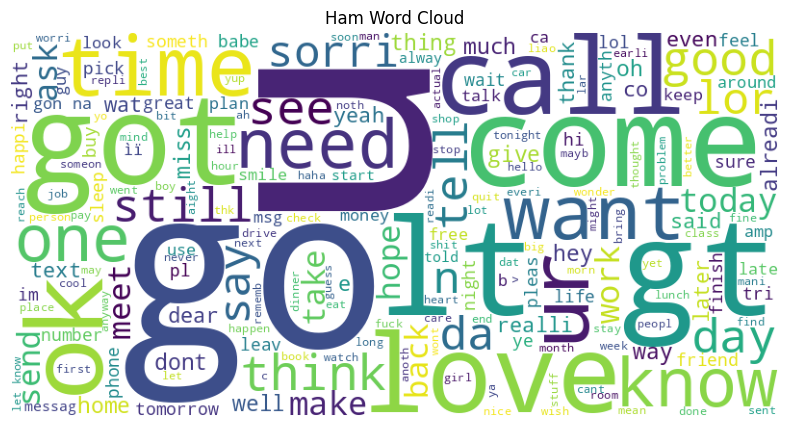

In [51]:
ham_text = " ".join(df[df["target"] == 0]["tranformed_text"])

wc = WordCloud(
    width=800,
    height=400,
    background_color="white"
)

ham_wc = wc.generate(ham_text)

plt.figure(figsize=(10,5))
plt.imshow(ham_wc)
plt.axis("off")
plt.title("Ham Word Cloud")
plt.show()

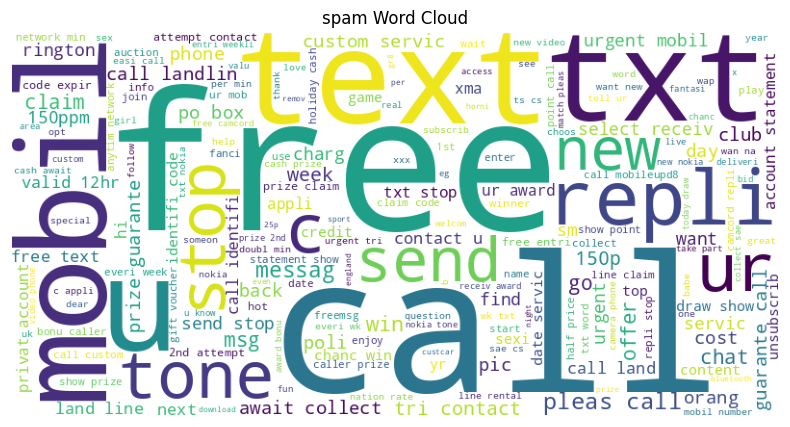

In [52]:
spam_text = " ".join(df[df["target"] == 1]["tranformed_text"])

wc = WordCloud(
    width=800,
    height=400,
    background_color="white"
)

spam_wc = wc.generate(spam_text)

plt.figure(figsize=(10,5))
plt.imshow(spam_wc)
plt.axis("off")
plt.title("spam Word Cloud")
plt.show()

In [80]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=3000,
                        ngram_range=(1,2),
                        min_df=2,
                        max_df=0.95
                       )

X = tfidf.fit_transform(df["tranformed_text"])

In [54]:

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer( max_features=5000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95
)

X = tfidf.fit_transform(df["tranformed_text"])

In [81]:
X.shape

(5169, 3000)

In [82]:
tfidf.get_feature_names_out()[:20]

array(['07xxxxxxxxx', '0800', '0800 542', '08000839402', '08000930705',
       '08000930705 deliveri', '08001950382', '08002986906', '0845',
       '0870', '0870 nation', '08701417012', '08701417012 profit',
       '08707509020', '08707509020 20p', '08712300220',
       '08712300220 quot', '08712405020', '08712460324', '08718720201'],
      dtype=object)

In [83]:
y =  df["target"].values

In [84]:
y

array([0, 0, 1, ..., 0, 0, 0], shape=(5169,))

In [85]:
from sklearn.model_selection import train_test_split

x_train , x_test , y_train , y_test = train_test_split(X,y,test_size = 0.2,random_state = 2)

In [86]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score

In [87]:
mnb = MultinomialNB()

In [88]:
mnb.fit(x_train , y_train)

MultinomialNB()

In [89]:
y_pred = mnb.predict(x_test)

In [90]:
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(precision_score(y_test,y_pred))

0.9738878143133463
[[896   0]
 [ 27 111]]
1.0


In [65]:
from sklearn.svm import LinearSVC

svc = LinearSVC(C=0.5)

svc.fit(x_train, y_train)

y_pred1 = svc.predict(x_test)

In [66]:
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.9738878143133463
[[893   3]
 [ 24 114]]
0.9743589743589743


In [67]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       896
           1       1.00      0.78      0.88       138

    accuracy                           0.97      1034
   macro avg       0.98      0.89      0.93      1034
weighted avg       0.97      0.97      0.97      1034



In [68]:

print(classification_report(y_test, y_pred1))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       896
           1       0.97      0.83      0.89       138

    accuracy                           0.97      1034
   macro avg       0.97      0.91      0.94      1034
weighted avg       0.97      0.97      0.97      1034



# Hence Multinomial Naive Bayes is good for this problem which give approx 97 % accuracy and 100% precision 

pickel

In [91]:
import pickle

In [92]:
with open("vectoizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)

In [93]:
with open("model.pkl", "wb") as f:
    pickle.dump(mnb, f)